# Traffic Forecasting in PyTorch

This notebook mirrors `example_rnn.ipynb`, but replaces the Keras models with PyTorch implementations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from helper import organize_data

np.random.seed(812)
torch.manual_seed(812)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### NOTE: If you are running this in JupyterLab, you will have to do the following:
+ Uncomment the "pip install" lines below and then run this cell. 
   This will install CPU-only PyTorch in your JupyterLab environment.
+ Wait until the installation completes.
+ Comment out the lines again, to prevent unnecessary re-installs.
+ Restart your kernel (Kernel>Restart kernel and clear output of all cells...)

In [ ]:
# %pip install --upgrade pip
# %pip install --extra-index-url https://download.pytorch.org/whl/cpu torch

# Load the data

In [2]:
rawdata = pd.read_csv("traffic_flows.csv")
rawdata["DateAndTimeTS"] = pd.to_datetime(rawdata["DateAndTime"])
rawdata = rawdata.set_index("DateAndTimeTS")
rawdata = rawdata.drop(columns="DateAndTime")
rawdata.head()

,Flow
DateAndTimeTS,
2018-01-01 00:00:00,3637.0
2018-01-01 01:00:00,3955.0
2018-01-01 02:00:00,3464.0
2018-01-01 03:00:00,2810.0
2018-01-01 04:00:00,2659.0


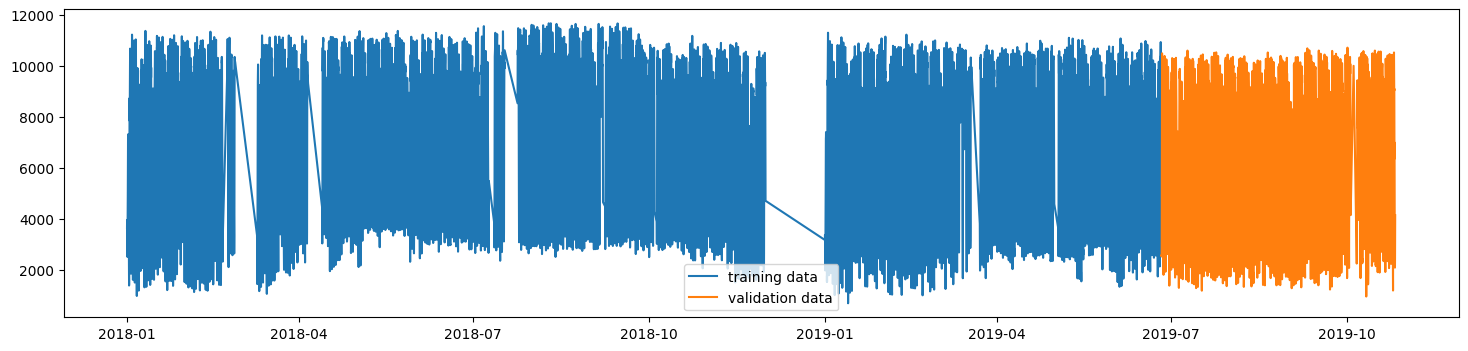

In [3]:
train_portion = 0.8
ind_split = int(train_portion * rawdata.shape[0])

data_train = rawdata.iloc[:ind_split].copy()
data_valid = rawdata.iloc[ind_split:].copy()

plt.figure(figsize=(18, 4))
plt.plot(data_train, label="training data")
plt.plot(data_valid, label="validation data")
plt.legend();

In [4]:
scaler = StandardScaler()
scaler = scaler.fit(data_train)

data_train["Flow scaled"] = scaler.transform(data_train)
data_valid["Flow scaled"] = scaler.transform(data_valid)

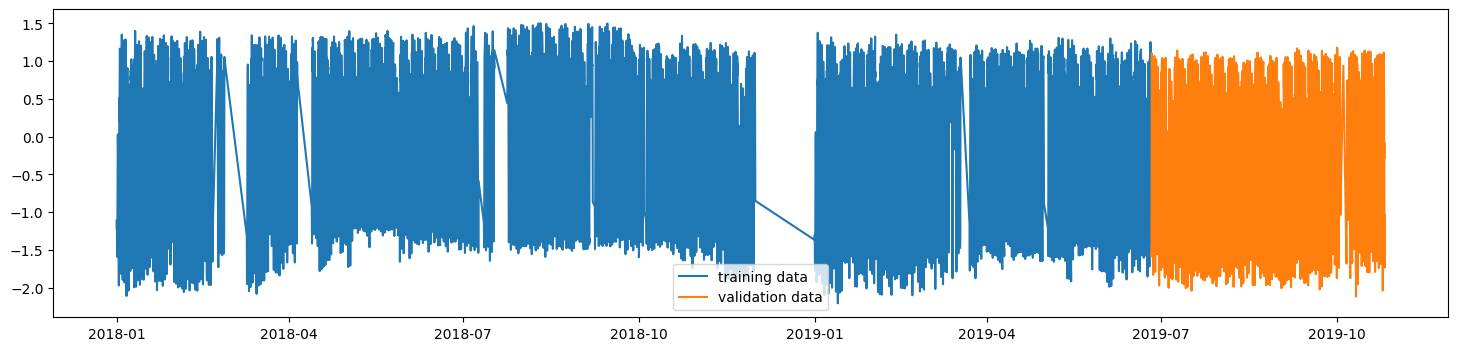

In [5]:
plt.figure(figsize=(18, 4))
plt.plot(data_train["Flow scaled"], label="training data")
plt.plot(data_valid["Flow scaled"], label="validation data")
plt.legend();

# Organize into input/output windows

In [6]:
T = 14
F = 3

Xtrain, ytrain, ttrainX, ttrainy = organize_data(data_train["Flow scaled"], F, T)
Xvalid, yvalid, tvalidX, tvalidy = organize_data(data_valid["Flow scaled"], F, T)

print("Xtrain shape:", Xtrain.shape)
print("Xvalid shape:", Xvalid.shape)

Xtrain shape: (11167, 14)
Xvalid shape: (2779, 14)


# Linear Regression Baseline

In [7]:
linreg = LinearRegression()
linreg.fit(Xtrain, ytrain)

linreg_r2_train = r2_score(ytrain, linreg.predict(Xtrain))
linreg_r2_valid = r2_score(yvalid, linreg.predict(Xvalid))

print(f"Training R2: {linreg_r2_train:.2f}")
print(f"Validation R2: {linreg_r2_valid:.2f}")

Training R2: 0.73
Validation R2: 0.69


# Prepare PyTorch Tensors and Helpers

In [8]:
Xtrain_mlp_t = torch.tensor(Xtrain, dtype=torch.float32)
Xvalid_mlp_t = torch.tensor(Xvalid, dtype=torch.float32)
ytrain_t = torch.tensor(ytrain, dtype=torch.float32).reshape(-1, 1)
yvalid_t = torch.tensor(yvalid, dtype=torch.float32).reshape(-1, 1)

Xtrain_seq_t = Xtrain_mlp_t.reshape(-1, T, 1)
Xvalid_seq_t = Xvalid_mlp_t.reshape(-1, T, 1)

train_loader_mlp = DataLoader(
    TensorDataset(Xtrain_mlp_t, ytrain_t),
    batch_size=32,
    shuffle=True
)

train_loader_seq = DataLoader(
    TensorDataset(Xtrain_seq_t, ytrain_t),
    batch_size=32,
    shuffle=True
)


def predict_torch(model, X_tensor, device=device):
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor.to(device))
    return predictions.cpu().numpy().reshape(-1)


def train_torch_model(
    model,
    train_loader,
    Xtrain_eval,
    ytrain_np,
    Xvalid_eval,
    yvalid_np,
    epochs=15,
    lr=0.001,
    device=device,
):
    model = model.to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "train_r2": [], "valid_r2": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        num_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            num_samples += X_batch.size(0)

        epoch_loss = running_loss / num_samples
        history["loss"].append(epoch_loss)

        train_pred = predict_torch(model, Xtrain_eval, device=device)
        valid_pred = predict_torch(model, Xvalid_eval, device=device)

        history["train_r2"].append(r2_score(ytrain_np, train_pred))
        history["valid_r2"].append(r2_score(yvalid_np, valid_pred))

    return model, history


class MLPModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 5),
            nn.ReLU(),
            nn.Linear(5, 1),
        )

    def forward(self, x):
        return self.model(x)


class SimpleRNNModel(nn.Module):
    def __init__(self, hidden_size=5):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)


class LSTMModel(nn.Module):
    def __init__(self, hidden_size=5):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

# MLP in PyTorch

In [9]:
model_mlp = MLPModel(input_dim=T)
model_mlp, history_mlp = train_torch_model(
    model_mlp,
    train_loader_mlp,
    Xtrain_mlp_t,
    ytrain,
    Xvalid_mlp_t,
    yvalid,
    epochs=15,
    lr=0.001,
)

mlp_r2_train = history_mlp["train_r2"][-1]
mlp_r2_valid = history_mlp["valid_r2"][-1]

print(f"Training R2: {mlp_r2_train:.2f}")
print(f"Validation R2: {mlp_r2_valid:.2f}")

Training R2: 0.86
Validation R2: 0.82


# Simple RNN in PyTorch

In [10]:
model_simprnn = SimpleRNNModel(hidden_size=5)
model_simprnn, history_simprnn = train_torch_model(
    model_simprnn,
    train_loader_seq,
    Xtrain_seq_t,
    ytrain,
    Xvalid_seq_t,
    yvalid,
    epochs=15,
    lr=0.001,
)

srnn_r2_train = history_simprnn["train_r2"][-1]
srnn_r2_valid = history_simprnn["valid_r2"][-1]

print(f"Training R2: {srnn_r2_train:.2f}")
print(f"Validation R2: {srnn_r2_valid:.2f}")

Training R2: 0.89
Validation R2: 0.89


# LSTM in PyTorch

In [11]:
model_lstm = LSTMModel(hidden_size=5)
model_lstm, history_lstm = train_torch_model(
    model_lstm,
    train_loader_seq,
    Xtrain_seq_t,
    ytrain,
    Xvalid_seq_t,
    yvalid,
    epochs=15,
    lr=0.001,
)

lstm_r2_train = history_lstm["train_r2"][-1]
lstm_r2_valid = history_lstm["valid_r2"][-1]

print(f"Training R2: {lstm_r2_train:.2f}")
print(f"Validation R2: {lstm_r2_valid:.2f}")

Training R2: 0.89
Validation R2: 0.88


# Compare Training Loss

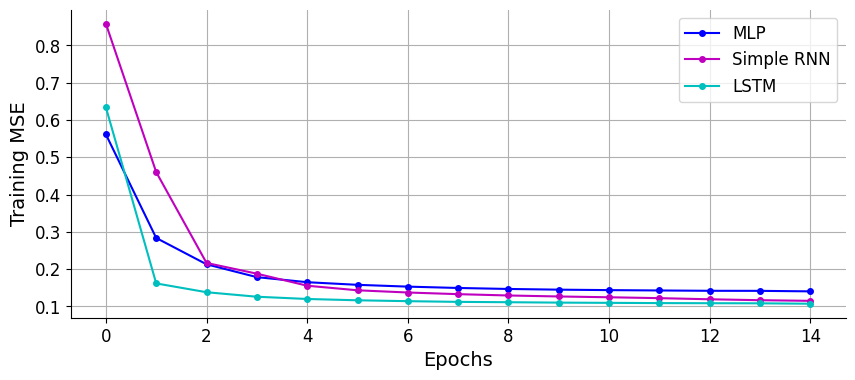

In [12]:
plt.figure(figsize=(10, 4))
ax = plt.subplot()
ax.plot(history_mlp["loss"], "b", marker="o", markersize=4, label="MLP")
ax.plot(history_simprnn["loss"], "m", marker="o", markersize=4, label="Simple RNN")
ax.plot(history_lstm["loss"], "c", marker="o", markersize=4, label="LSTM")
ax.legend(fontsize=12)
ax.grid(":")
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Training MSE", fontsize=14)
plt.show()